##Step 1: Load and Inspect the Dataset

In [7]:
# Import necessary libraries
import pandas as pd

# Load the dataset
data = pd.read_csv('/content/heart.csv')  # Replace 'heart.csv' with the correct file path

# Display the first few rows
print(data.head())

# Get information about the dataset
print(data.info())

# Check for missing values
print(data.isnull().sum())


   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   3       145   233    1        0      150      0      2.3      0   
1   37    1   2       130   250    0        1      187      0      3.5      0   
2   41    0   1       130   204    0        0      172      0      1.4      2   
3   56    1   1       120   236    0        1      178      0      0.8      2   
4   57    0   0       120   354    0        1      163      1      0.6      2   

   ca  thal  target  
0   0     1       1  
1   0     2       1  
2   0     2       1  
3   0     2       1  
4   0     2       1  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5 

##Step 2: Data Preprocessing

In [8]:
#Handle Missing Values:
# Check for missing values
print(data.isnull().sum())

# If missing values exist, fill or drop them
# Example: data = data.dropna()


age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [9]:
#Encode Categorical Variables:
# Identify categorical columns and apply one-hot encoding
categorical_cols = ['cp', 'restecg', 'slope', 'thal', 'ca']
data = pd.get_dummies(data, columns=categorical_cols, drop_first=True)



In [10]:
#Scale Numerical Features:
from sklearn.preprocessing import StandardScaler

# List of numerical columns to scale
numerical_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

# Scale the numerical data
scaler = StandardScaler()
data[numerical_cols] = scaler.fit_transform(data[numerical_cols])


##Step 3: Exploratory Data Analysis (EDA)

#Perform visual and statistical analyses to understand trends and relationships.
Correlation Heatmap:

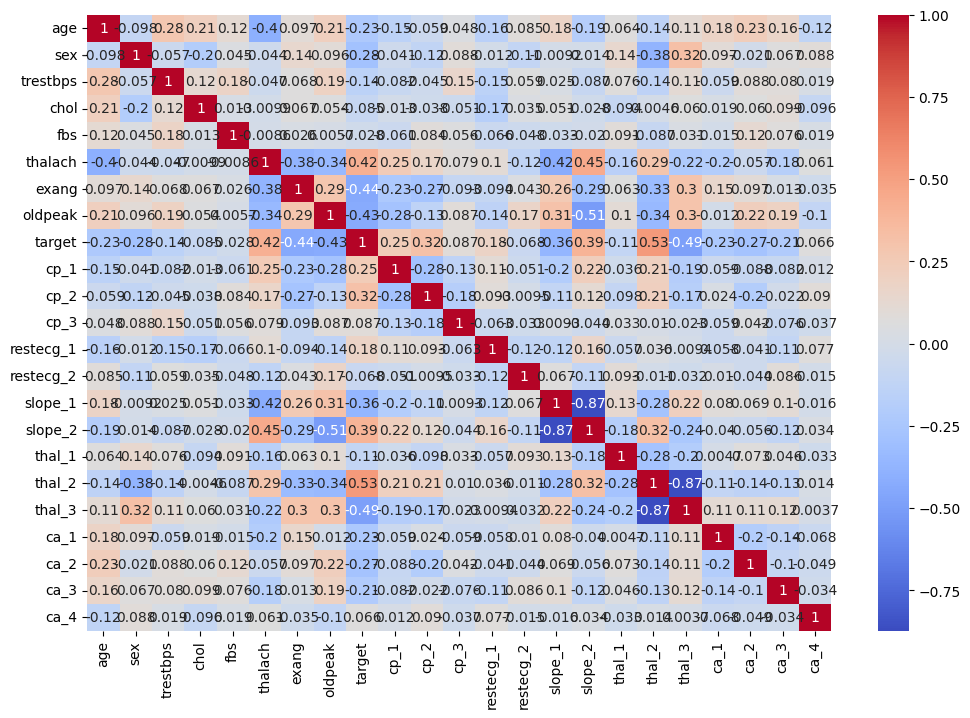

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

# Correlation matrix
corr_matrix = data.corr()

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.show()


Distribution of Target Variable:

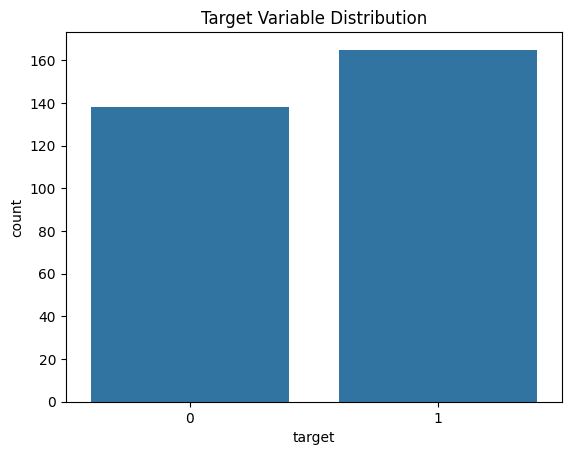

In [12]:
# Plot the target variable distribution
sns.countplot(x='target', data=data)
plt.title('Target Variable Distribution')
plt.show()


##Additional visualizationr Exploratory Data Analysis

## 1. Pairplot for Feature Relationships

A pairplot shows scatterplots for feature relationships and distributions for numerical variables.

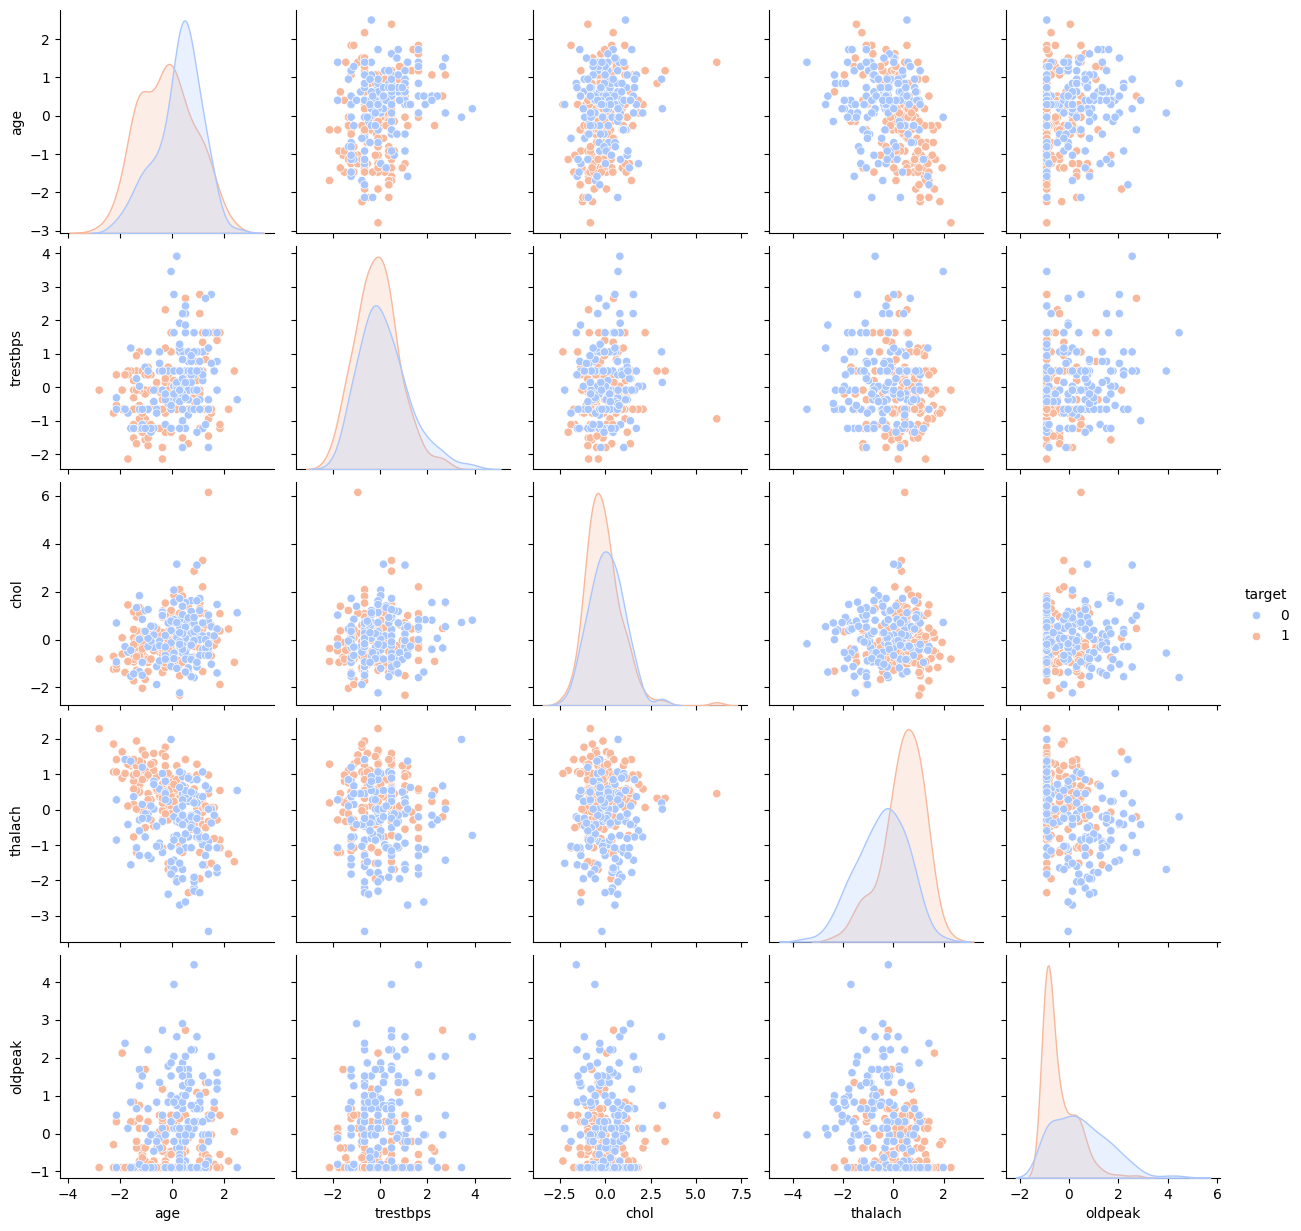

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

# Pairplot of selected numerical features
selected_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'target']
sns.pairplot(data[selected_features], hue='target', diag_kind='kde', palette='coolwarm')
plt.show()


## 2. Count Plot of Categorical Features

Visualize the distribution of categorical features like cp (chest pain type) or thal.

In [14]:
# Count plot for a categorical feature
sns.countplot(x='cp', hue='target', data=data, palette='coolwarm')
plt.title('Chest Pain Type vs Target')
plt.show()


ValueError: Could not interpret value `cp` for `x`. An entry with this name does not appear in `data`.

## 3. Distribution of Numerical Features
Visualize the distribution of important numerical features using histograms or density plots.

In [ ]:
# Distribution plots for numerical features
numerical_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

for feature in numerical_features:
    plt.figure()
    sns.histplot(data[feature], kde=True, bins=30, color='blue')
    plt.title(f'Distribution of {feature}')
    plt.show()


## 4. Boxplots to Detect Outliers

In [ ]:
# Boxplots for numerical features
for feature in numerical_features:
    plt.figure()
    sns.boxplot(data=data, x='target', y=feature, palette='coolwarm')
    plt.title(f'{feature} vs Target')
    plt.show()


##5. Bar Plot for Feature Importance

Visualize feature importance based on model coefficients.

In [ ]:
# Sort features by absolute value of coefficients
coef_df = coef_df.sort_values(by='AbsCoefficient', ascending=True)

# Bar plot of coefficients
plt.figure(figsize=(10, 6))
sns.barplot(x='AbsCoefficient', y='Feature', data=coef_df, palette='viridis')
plt.title('Feature Importance (Absolute Coefficients)')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.show()


##6. Heatmap for Class Imbalance

In [ ]:
# Heatmap of class imbalance with chest pain types
heatmap_data = pd.crosstab(data['cp'], data['target'])
sns.heatmap(heatmap_data, annot=True, cmap='coolwarm', fmt='d')
plt.title('Chest Pain Type vs Target')
plt.xlabel('Target')
plt.ylabel('Chest Pain Type')
plt.show()


##7. KDE Plots

KDE (Kernel Density Estimate) plots help visualize the distribution of a feature with respect to the target variable.

In [ ]:
# KDE plot for features
for feature in numerical_features:
    plt.figure()
    sns.kdeplot(data=data, x=feature, hue='target', shade=True, palette='coolwarm')
    plt.title(f'KDE Plot for {feature} by Target')
    plt.show()


##Step 4: Split Data into Training and Testing Sets

Divide the dataset into features (X) and target variable (y), then split into training and testing subsets.

In [ ]:
from sklearn.model_selection import train_test_split

# Features and target variable
X = data.drop('target', axis=1)
y = data['target']

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


##Step 5: Train the Logistic Regression Model
Build the logistic regression model using the training data.

In [ ]:
from sklearn.linear_model import LogisticRegression

# Initialize and train the model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)


##Step 6: Evaluate the Model
Use performance metrics to evaluate the model’s predictions.

Make Predictions:

In [ ]:
# Predict on test data
y_pred = model.predict(X_test)


Metrics Evaluation:

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print('Accuracy:', accuracy)
print('Precision:', precision)
print('Recall:', recall)
print('F1 Score:', f1)

# Predict probabilities for ROC curve
y_pred_proba = model.predict_proba(X_test)[:, 1]

# ROC-AUC
auc = roc_auc_score(y_test, y_pred_proba)
print('ROC-AUC Score:', auc)


ROC Curve:

In [ ]:
# Plot ROC curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.figure()
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], 'r--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()


##Step 7: Interpret Model Coefficients

Understand the significance of features in the prediction.



In [ ]:
# Feature importance
coefficients = model.coef_[0]
features = X.columns

# Create a DataFrame for visualization
coef_df = pd.DataFrame({'Feature': features, 'Coefficient': coefficients})
coef_df['AbsCoefficient'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values(by='AbsCoefficient', ascending=False)

print(coef_df)
